# Visualizing Chipotle's Data

This time we are going to pull data directly from the internet.
Special thanks to: https://github.com/justmarkham for sharing the dataset and materials.

### Step 1. Import the necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# set this so the graphs open internally
%matplotlib inline

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv).

### Step 3. Assign it to a variable called chipo.

In [6]:
#기본 파일이 tsv라서 탭구분자 사용

url = 'https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv'
chipo = pd.read_csv(url, sep='\t')

### Step 4. See the first 10 entries

In [7]:
chipo.head(10)

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",$10.98
6,3,1,Side of Chips,NaN,$1.69
7,4,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",$11.75
8,4,1,Steak Soft Tacos,"[Tomatillo Green Chili Salsa, [Pinto Beans, Ch...",$9.25
9,5,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Pinto...",$9.25


### Step 5. Create a histogram of the top 5 items bought

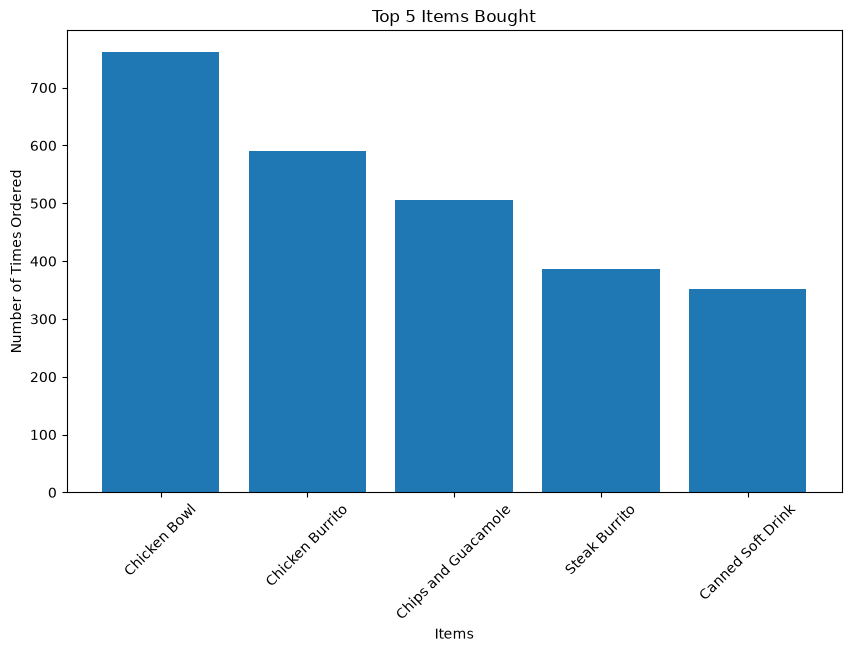

In [15]:
#item_name별로 그룹화 / 구매량을 합함 / 내림차순으로 5개 정렬하기 
top5 = chipo.groupby('item_name')['quantity'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 6))
plt.bar(x=top5.index, height=top5.values)
plt.title('Top 5 Items Bought')
plt.xlabel('Items')
plt.ylabel('Number of Times Ordered')
plt.xticks(rotation=45)
plt.show()

### Step 6. Create a scatterplot with the number of items orderered per order price
#### Hint: Price should be in the X-axis and Items ordered in the Y-axis

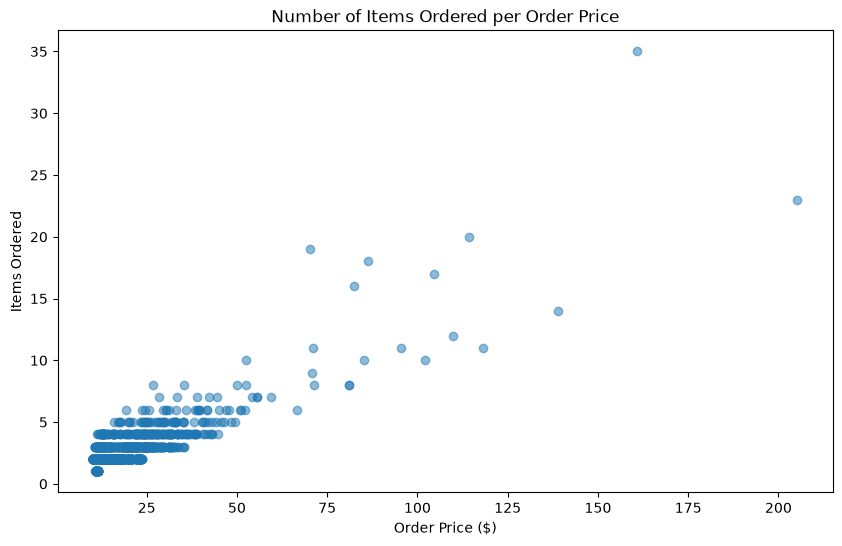

In [17]:
# item_price 컬럼의 달러 기호($) 제거 후 float 형변환
chipo['item_price_num'] = chipo['item_price'].str.replace('$', '').astype(float)

# order_id 기준으로 총 주문 금액(X축)과 총 주문 수량(Y축) 집계
orders = chipo.groupby('order_id').agg({
    'item_price_num': 'sum',
    'quantity': 'sum'
})

# 산점도 시각화
plt.figure(figsize=(10, 6))
plt.scatter(orders['item_price_num'], orders['quantity'], alpha=0.5)
plt.title('Number of Items Ordered per Order Price')
plt.xlabel('Order Price ($)')
plt.ylabel('Items Ordered')
plt.show()

### Step 7. BONUS: Create a question and a graph to answer your own question.

상위 5개 상품의 가격 분포를 비교하는 boxplot 생성하기 

<Figure size 1000x600 with 0 Axes>

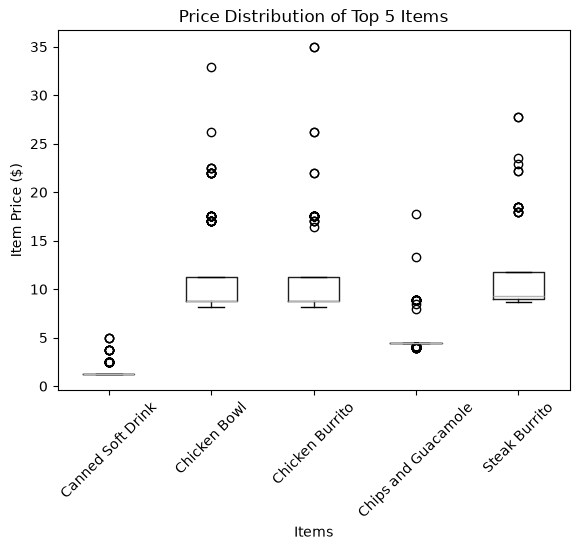

In [19]:
# 1. 상위 5개 아이템 이름 추출
top5_items = chipo.groupby('item_name')['quantity'].sum().sort_values(ascending=False).head(5).index

# 2. 상위 5개 아이템에 해당하는 데이터만 필터링
top5_df = chipo[chipo['item_name'].isin(top5_items)]

# 3. 아이템별 가격 분포 boxplot 작성
plt.figure(figsize=(10, 6))
top5_df.boxplot(column='item_price_num', by='item_name', grid=False) #grid 눈금선 표시
plt.title('Price Distribution of Top 5 Items')
plt.suptitle('')  # 자동 생성되는 판다스 서브타이틀 제거
plt.xlabel('Items')
plt.ylabel('Item Price ($)')
plt.xticks(rotation=45)
plt.show()